# Ejercicio 1

1. Realice la carga y visualización de diferentes imágenes.
2. Muestre en pantalla información sobre las imágenes.
3. Investigue los formatos de la imagen y cómo leer y cómo escribir un valor puntual de la imagen.
4. Utilice el pasaje por parámetros para especificar la imagen a cargar.
5. Define y recorte una subimagen de una imagen (vea ROI, Region Of Interest).
6. Investigue y realice una función que le permita mostrar varias imágenes en una sóla ventana.
7. Dibuje sobre la imagen líneas, círculos y rectángulos (opcional: defina la osición en base al click del mouse).


## Cargar imágenes

In [1]:
import cv2
import matplotlib.pyplot as plt

img_bgr = cv2.imread("firewatch.png")
img2_bgr = cv2.imread("ow.png")

print("Dimensiones de la imagen 1: ", img_bgr.shape)
print("Tipo de dato de la imagen 1: ", img_bgr.dtype)
print("Color en [100, 100]: ", img_bgr[100, 100])

print("Dimensiones de la imagen 2: ", img2_bgr.shape)
print("Tipo de dato de la imagen 2: ", img2_bgr.dtype)
print("Color en [100, 100]: ", img_bgr[100, 100])

Dimensiones de la imagen 1:  (675, 1200, 3)
Tipo de dato de la imagen 1:  uint8
Color en [100, 100]:  [198 220 255]
Dimensiones de la imagen 2:  (1080, 1920, 3)
Tipo de dato de la imagen 2:  uint8
Color en [100, 100]:  [198 220 255]


## Modificar imágenes

In [2]:
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_hls = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HLS)

img2_gray = cv2.cvtColor(img2_bgr, cv2.COLOR_BGR2GRAY)
img2_rgb = cv2.cvtColor(img2_bgr, cv2.COLOR_BGR2RGB)
img2_hls = cv2.cvtColor(img2_bgr, cv2.COLOR_BGR2HLS)

# ROI
img_roi = img_bgr[50:400, 400:800].copy()
img2_roi = img2_bgr[400:, 1000:].copy()

# Dibujar
cv2.line(img_roi, (0,250), (400,250), (255,0,0), 5)
cv2.line(img2_roi, (400,700), (1000,300), (255,0,0), 5)
cv2.rectangle(img_roi, (100,300), (300,50), (0,255,0), 2)
cv2.rectangle(img2_roi, (650,300), (900,50), (0,255,0), 2)
cv2.circle(img_roi, (200,150), 50, (255,0,0), 2)
cv2.circle(img2_roi, (400,300), 50, (255,0,0), 2);

## Mostrar imágenes

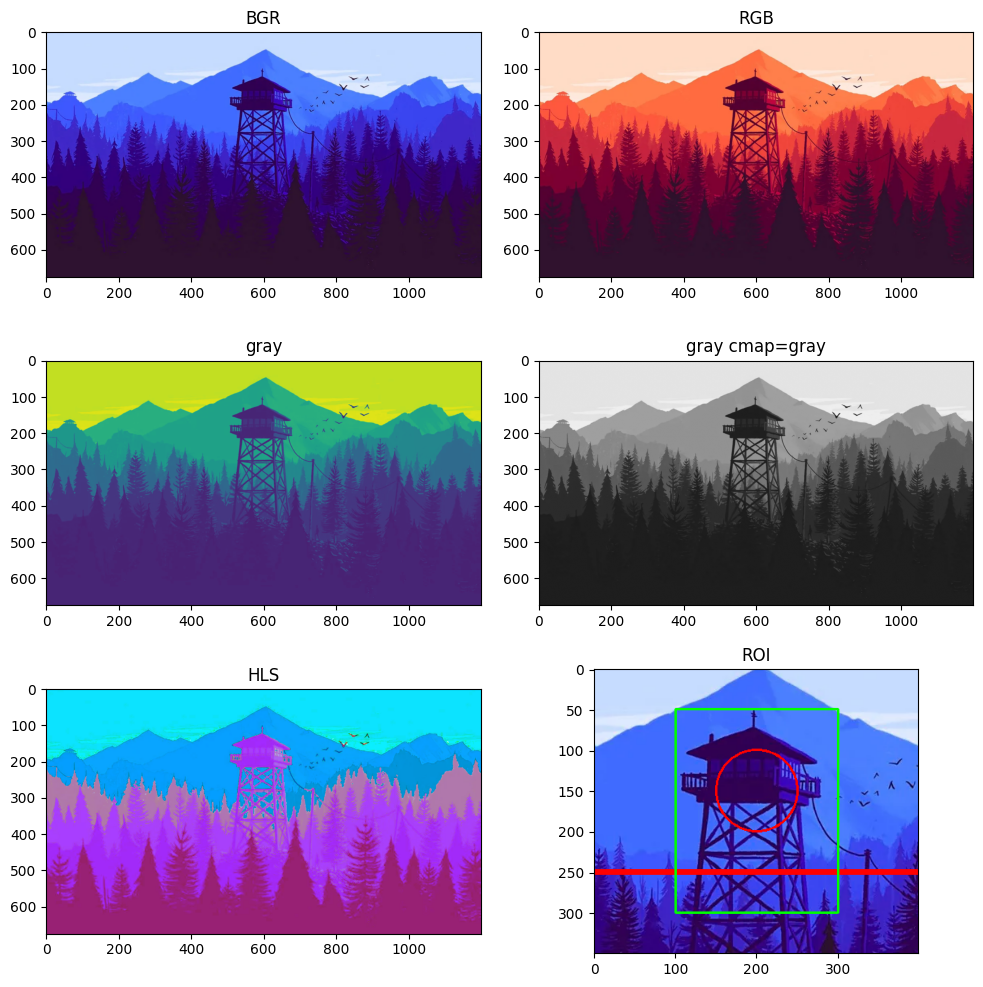

In [3]:
fig, ax = plt.subplots(3, 2)
fig.set_figwidth(10)
fig.set_figheight(10)
fig.tight_layout()

ax[0,0].set_title("BGR")
ax[0,0].imshow(img_bgr)
ax[0,1].set_title("RGB")
ax[0,1].imshow(img_rgb)
ax[1,0].set_title("gray")
ax[1,0].imshow(img_gray)
ax[1,1].set_title("gray cmap=gray")
ax[1,1].imshow(img_gray, cmap="gray", vmin=0, vmax=255)
ax[2,0].set_title("HLS")
ax[2,0].imshow(img_hls)
ax[2,1].set_title("ROI")
ax[2,1].imshow(img_roi)

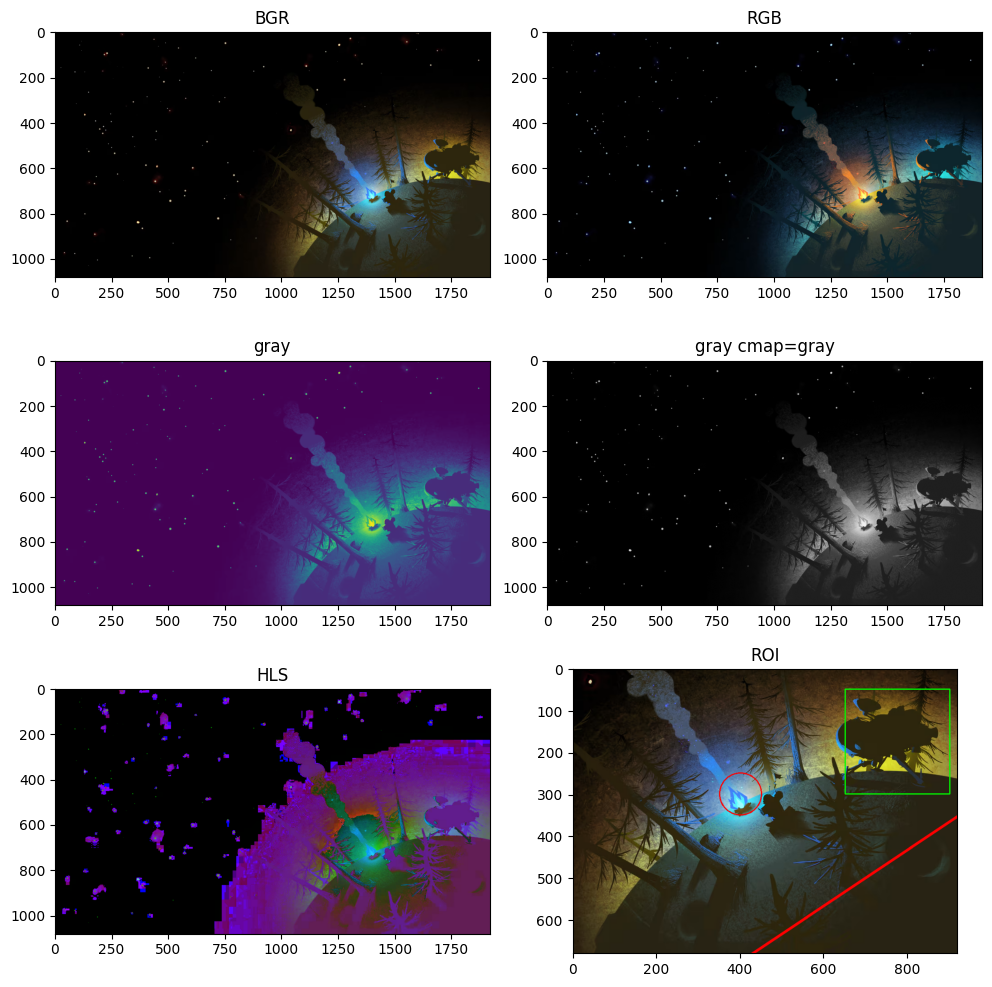

In [4]:
fig, ax = plt.subplots(3, 2)
fig.set_figwidth(10)
fig.set_figheight(10)
fig.tight_layout()

ax[0,0].set_title("BGR")
ax[0,0].imshow(img2_bgr)
ax[0,1].set_title("RGB")
ax[0,1].imshow(img2_rgb)
ax[1,0].set_title("gray")
ax[1,0].imshow(img2_gray)
ax[1,1].set_title("gray cmap=gray")
ax[1,1].imshow(img2_gray, cmap="gray", vmin=0, vmax=255)
ax[2,0].set_title("HLS")
ax[2,0].imshow(img2_hls)
ax[2,1].set_title("ROI")
ax[2,1].imshow(img2_roi)

## Dibujado por mouse

In [ ]:
clone = img_bgr.copy()

clicked = False # False: estado inicial -[click]-> True: primer punto seleccionado
p1 = (-1, -1)

def click_event(event, x, y, flags, param):
    global clicked, p1
    if event == cv2.EVENT_LBUTTONDOWN:
        if clicked: # segundo click
            clicked = False
            cv2.rectangle(img_bgr, p1, (x, y), (0,255,0), 2)
        else:   # primer click
            clicked = True
            p1 = (x, y)

cv2.namedWindow('Ej 1')
cv2.setMouseCallback('Ej 1', click_event)

while True:
    cv2.imshow('Ej 1', img_bgr)
    if cv2.waitKey(1) & 0xFF == 27: # 27: ESC en ASCII
        break

cv2.destroyAllWindows()